In [4]:
# Install required packages
print("📦 Installing required packages...")

!pip install -q opendatasets pandas numpy matplotlib seaborn wordcloud openpyxl

print("✅ All packages installed successfully!")

📦 Installing required packages...
✅ All packages installed successfully!


In [5]:
import os

# Main project folder
base_path = '/content/sepedi_rabies_eda'
os.makedirs(base_path, exist_ok=True)

# Create subdirectories
dirs = [
    'data/raw',          # Raw downloaded Excel files
    'data/processed',    # Combined CSV for chatbot
    'figures',           # Saved plots
    'notebooks'          # (optional) for any extra notebooks
]

for d in dirs:
    full_path = os.path.join(base_path, d)
    os.makedirs(full_path, exist_ok=True)
    print(f"📁 Created → {full_path}")

print(f"\n✅ Project root: {base_path}")

📁 Created → /content/sepedi_rabies_eda/data/raw
📁 Created → /content/sepedi_rabies_eda/data/processed
📁 Created → /content/sepedi_rabies_eda/figures
📁 Created → /content/sepedi_rabies_eda/notebooks

✅ Project root: /content/sepedi_rabies_eda


In [7]:
# Download the zip file using wget (no credentials needed!)
!wget https://github.com/MuphulusiDzivhani/Rabies-chatbot/raw/main/Nicd%20data.zip

# Create a directory for the data
!mkdir -p /content/sepedi_rabies_data

# Unzip the files
!unzip -q "Nicd data.zip" -d /content/sepedi_rabies_data/

# Check what we got
import os
import glob
data_path = "/content/sepedi_rabies_data/"
files = glob.glob(data_path + "*.xlsx")
print(f"Found {len(files)} Excel files:")
for f in files:
    print(f"  - {os.path.basename(f)}")

--2026-03-15 20:06:51--  https://github.com/MuphulusiDzivhani/Rabies-chatbot/raw/main/Nicd%20data.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MuphulusiDzivhani/Rabies-chatbot/main/Nicd%20data.zip [following]
--2026-03-15 20:06:51--  https://raw.githubusercontent.com/MuphulusiDzivhani/Rabies-chatbot/main/Nicd%20data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197031 (192K) [application/zip]
Saving to: ‘Nicd data.zip’

Nicd data.zip       100%[===================>] 192.41K  --.-KB/s    in 0.06s   

2026-03-15 20:06:52 (3.25 MB/s) - ‘Nicd data.zip’ saved [197031/197031]

Found 14 Ex

In [8]:
# Cell 4: Load all Excel files for EDA
import pandas as pd
import glob
import os

data_path = "/content/sepedi_rabies_data/"
files = glob.glob(data_path + "*.xlsx")
print(f"Found {len(files)} files")

data_frames = {}
for file in files:
    name = os.path.basename(file).replace('.xlsx', '')
    df = pd.read_excel(file)
    data_frames[name] = df
    print(f"✅ {name}: {df.shape}")

Found 14 files
✅ rabies_topic2_prevention_control_sepedi_v1: (10, 4)
✅ rabies_topic3_virology_diagnosis_sepedi_v1: (10, 4)
✅ rabies_topic5_geography_risk_areas_sepedi_v1: (10, 4)
✅ rabies_topic3_virology_diagnosis_sepedi_v2: (10, 4)
✅ Test _epidemiology_surveillance_v1: (9, 2)
✅ TestQuestions_translated_v1_NLLB_TN: (9, 5)
✅ rabies_topic6_public_awareness_education_sepedi_v1: (10, 4)
✅ rabies_topic6_public_awareness_education_sepedi_v2: (10, 4)
✅ rabies_topic4_case_definition_clinical_sepedi_v1: (10, 5)
✅ rabies_topic4_case_definition_clinical_sepedi_v2: (10, 4)
✅ rabies_topic5_geography_risk_areas_sepedi_v2: (10, 4)
✅ rabies_topic1_epidemiology_surveillance_sepedi_v1: (10, 4)
✅ Test questions_v1: (9, 2)
✅ rabies_topic2_prevention_control_sepedi_v2: (10, 4)


In [9]:
# Filter only the main topic files (those starting with "rabies_topic")
main_files = {name: df for name, df in data_frames.items() if name.startswith('rabies_topic')}
print(f"Main topic files: {len(main_files)}")
for name, df in main_files.items():
    print(f"  {name}: {df.shape}")

Main topic files: 11
  rabies_topic2_prevention_control_sepedi_v1: (10, 4)
  rabies_topic3_virology_diagnosis_sepedi_v1: (10, 4)
  rabies_topic5_geography_risk_areas_sepedi_v1: (10, 4)
  rabies_topic3_virology_diagnosis_sepedi_v2: (10, 4)
  rabies_topic6_public_awareness_education_sepedi_v1: (10, 4)
  rabies_topic6_public_awareness_education_sepedi_v2: (10, 4)
  rabies_topic4_case_definition_clinical_sepedi_v1: (10, 5)
  rabies_topic4_case_definition_clinical_sepedi_v2: (10, 4)
  rabies_topic5_geography_risk_areas_sepedi_v2: (10, 4)
  rabies_topic1_epidemiology_surveillance_sepedi_v1: (10, 4)
  rabies_topic2_prevention_control_sepedi_v2: (10, 4)


In [10]:
# For each main file, ensure we have the expected 4 columns

for name, df in main_files.items():
    # If there's an extra unnamed column, drop it
    if df.shape[1] > 4:
        # Assume first 4 columns are the ones we need
        df = df.iloc[:, :4]
        df.columns = ['question_sepedi', 'answer_sepedi', 'question_english', 'answer_english']
        main_files[name] = df
        print(f"Cleaned {name}: {df.shape}")

Cleaned rabies_topic4_case_definition_clinical_sepedi_v1: (10, 4)


In [11]:
def add_length_features(df):
    df['q_sepedi_len'] = df['question_sepedi'].astype(str).apply(len)
    df['a_sepedi_len'] = df['answer_sepedi'].astype(str).apply(len)
    df['q_english_len'] = df['question_english'].astype(str).apply(len)
    df['a_english_len'] = df['answer_english'].astype(str).apply(len)
    return df

for name, df in main_files.items():
    main_files[name] = add_length_features(df)

print("✅ Length features added to all main files.")

✅ Length features added to all main files.


In [12]:
import pandas as pd

all_main = pd.concat(
    [df.assign(source=name) for name, df in main_files.items()],
    ignore_index=True
)
print(f"Combined main dataset: {all_main.shape[0]} rows, {all_main.shape[1]} columns")

Combined main dataset: 110 rows, 9 columns


In [13]:
def extract_topic(source):
    if 'topic1' in source:
        return 'Epidemiology'
    elif 'topic2' in source:
        return 'Prevention'
    elif 'topic3' in source:
        return 'Virology'
    elif 'topic4' in source:
        return 'Clinical'
    elif 'topic5' in source:
        return 'Geography'
    elif 'topic6' in source:
        return 'Public Awareness'
    else:
        return 'Other'

def extract_version(source):
    return 'v2' if 'v2' in source else 'v1'

all_main['topic'] = all_main['source'].apply(extract_topic)
all_main['version'] = all_main['source'].apply(extract_version)

print("Topic distribution:")
print(all_main['topic'].value_counts())
print("\nVersion distribution:")
print(all_main['version'].value_counts())

Topic distribution:
topic
Prevention          20
Virology            20
Geography           20
Public Awareness    20
Clinical            20
Epidemiology        10
Name: count, dtype: int64

Version distribution:
version
v1    60
v2    50
Name: count, dtype: int64


In [14]:
length_cols = ['q_sepedi_len', 'a_sepedi_len', 'q_english_len', 'a_english_len']
stats = all_main[length_cols].describe().round(1)
print("Text length statistics (characters):")
stats

Text length statistics (characters):


,q_sepedi_len,a_sepedi_len,q_english_len,a_english_len
count,110.0,110.0,110.0,110.0
mean,67.7,105.5,45.9,67.9
std,14.8,21.9,12.0,13.4
min,35.0,23.0,3.0,3.0
25%,58.2,90.0,38.5,61.0
50%,66.0,107.0,44.5,70.0
75%,78.2,123.0,50.8,74.0
max,108.0,146.0,103.0,109.0


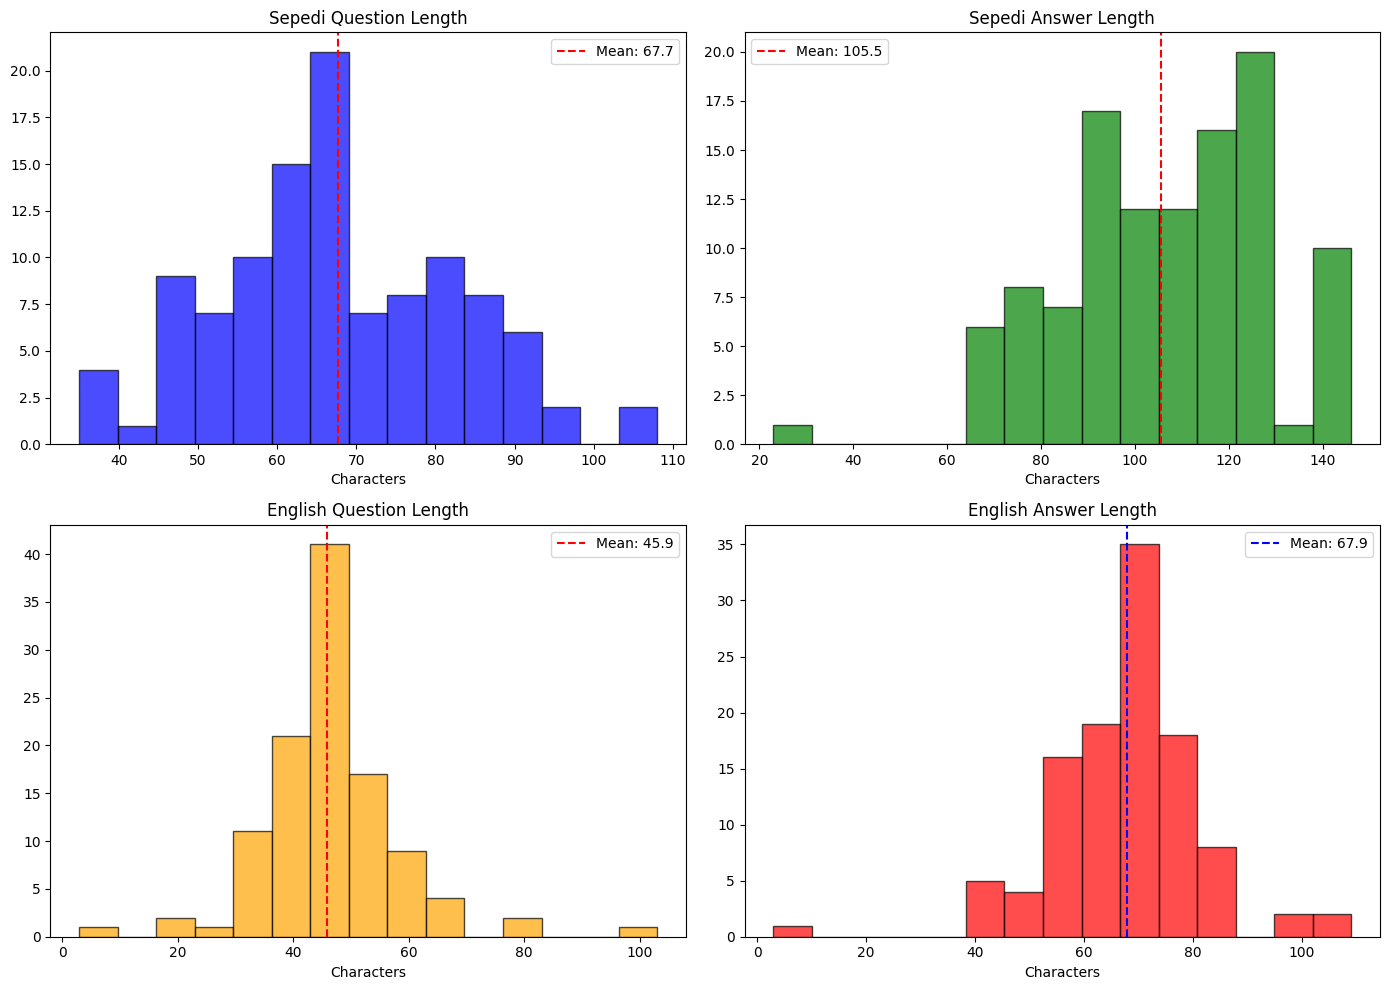

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(all_main['q_sepedi_len'], bins=15, edgecolor='black', alpha=0.7, color='blue')
axes[0,0].axvline(all_main['q_sepedi_len'].mean(), color='red', linestyle='--', label=f"Mean: {all_main['q_sepedi_len'].mean():.1f}")
axes[0,0].set_title('Sepedi Question Length')
axes[0,0].set_xlabel('Characters')
axes[0,0].legend()

axes[0,1].hist(all_main['a_sepedi_len'], bins=15, edgecolor='black', alpha=0.7, color='green')
axes[0,1].axvline(all_main['a_sepedi_len'].mean(), color='red', linestyle='--', label=f"Mean: {all_main['a_sepedi_len'].mean():.1f}")
axes[0,1].set_title('Sepedi Answer Length')
axes[0,1].set_xlabel('Characters')
axes[0,1].legend()

axes[1,0].hist(all_main['q_english_len'], bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1,0].axvline(all_main['q_english_len'].mean(), color='red', linestyle='--', label=f"Mean: {all_main['q_english_len'].mean():.1f}")
axes[1,0].set_title('English Question Length')
axes[1,0].set_xlabel('Characters')
axes[1,0].legend()

axes[1,1].hist(all_main['a_english_len'], bins=15, edgecolor='black', alpha=0.7, color='red')
axes[1,1].axvline(all_main['a_english_len'].mean(), color='blue', linestyle='--', label=f"Mean: {all_main['a_english_len'].mean():.1f}")
axes[1,1].set_title('English Answer Length')
axes[1,1].set_xlabel('Characters')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('length_distributions.png', dpi=150)
plt.show()

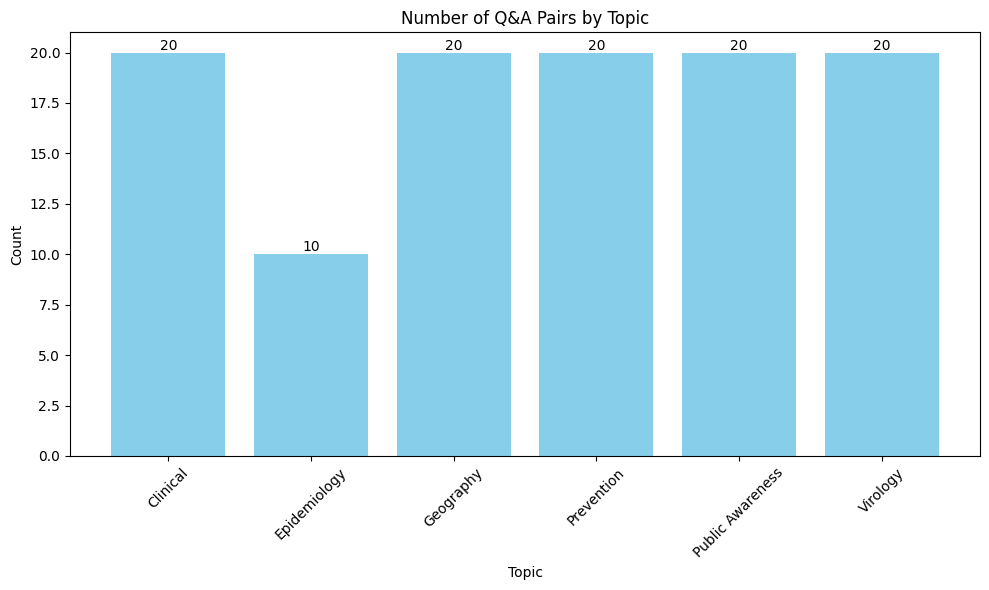

In [16]:
topic_counts = all_main.groupby('topic').size().reset_index(name='count')
plt.figure(figsize=(10,6))
bars = plt.bar(topic_counts['topic'], topic_counts['count'], color='skyblue')
plt.title('Number of Q&A Pairs by Topic')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150)
plt.show()

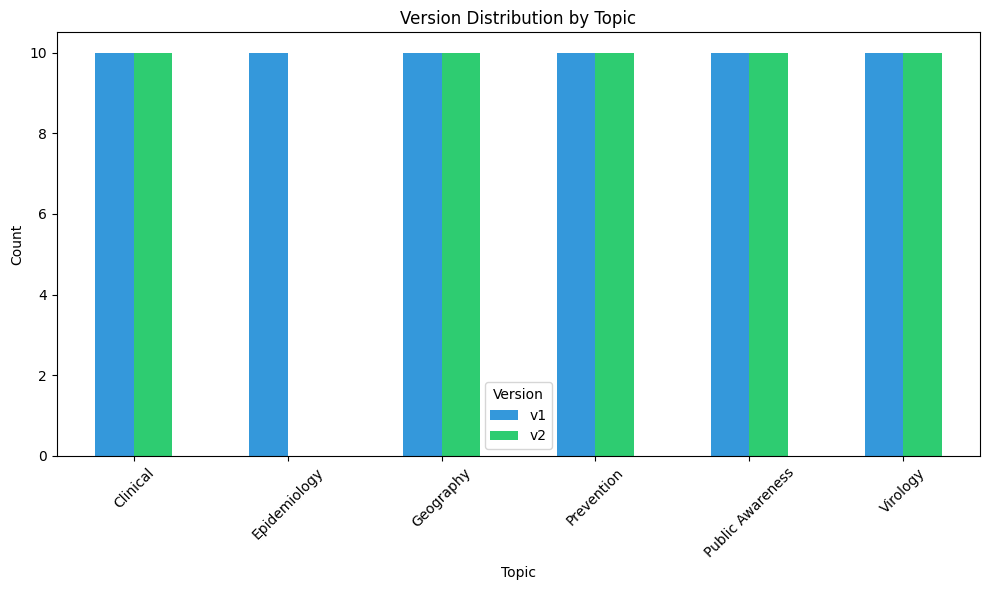

In [17]:
version_counts = all_main.groupby(['topic', 'version']).size().unstack(fill_value=0)
version_counts.plot(kind='bar', figsize=(10,6), color=['#3498db', '#2ecc71'])
plt.title('Version Distribution by Topic')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.legend(title='Version')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('version_comparison.png', dpi=150)
plt.show()

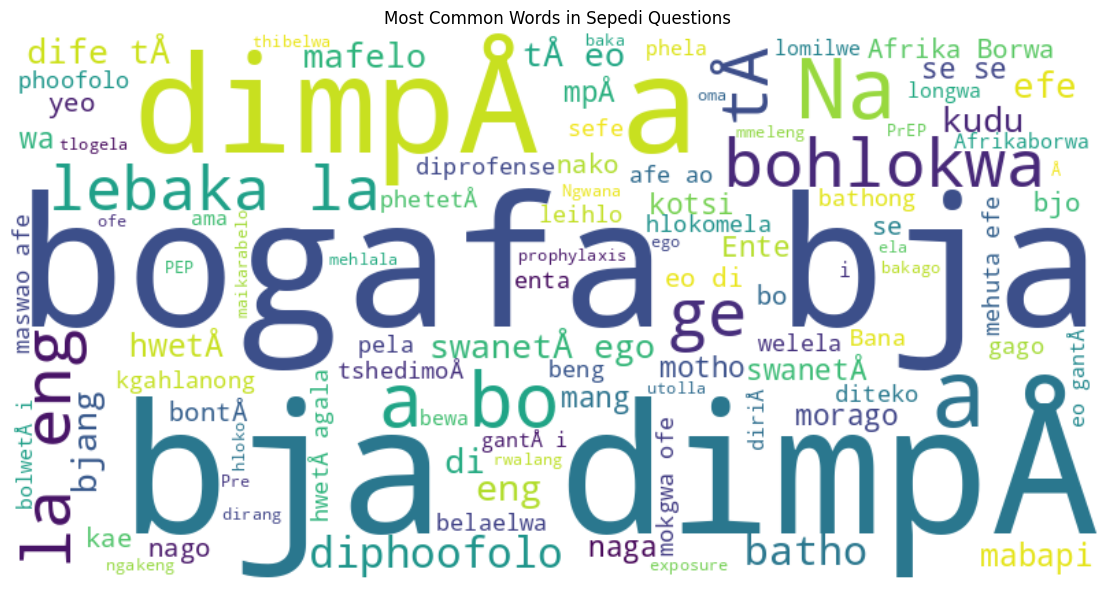

In [18]:
from wordcloud import WordCloud

text = ' '.join(all_main['question_sepedi'].astype(str).tolist())
stopwords = set(['ke', 'go', 'le', 'ya', 'ba', 'e', 'o', 'sa', 'ka', 'tša', 'tše', 'mo', 'ga', 'gore', 'ye'])

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, max_words=100).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Sepedi Questions')
plt.tight_layout()
plt.savefig('sepedi_wordcloud.png', dpi=150)
plt.show()

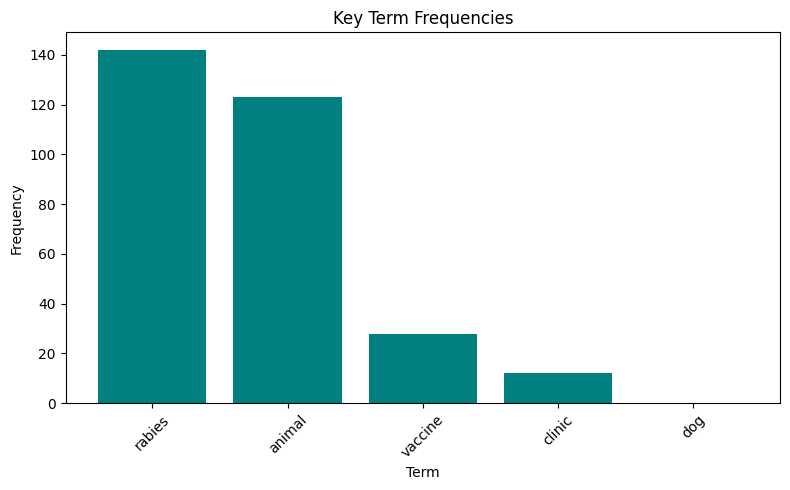

In [19]:
key_terms = {
    'rabies': ['bogafa', 'rabies'],
    'dog': ['mpša', 'dimpša'],
    'vaccine': ['ente', 'enta'],
    'animal': ['phoofolo', 'diphoofolo'],
    'clinic': ['kliniking', 'bookelong']
}

freq = {}
for term, keywords in key_terms.items():
    count = 0
    for kw in keywords:
        count += all_main['question_sepedi'].str.contains(kw, case=False, na=False).sum()
        count += all_main['answer_sepedi'].str.contains(kw, case=False, na=False).sum()
    freq[term] = count

freq_df = pd.DataFrame(list(freq.items()), columns=['Term', 'Frequency']).sort_values('Frequency', ascending=False)
freq_df

plt.figure(figsize=(8,5))
plt.bar(freq_df['Term'], freq_df['Frequency'], color='teal')
plt.title('Key Term Frequencies')
plt.xlabel('Term')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('term_frequency.png', dpi=150)
plt.show()

In [20]:
# Select relevant columns
chatbot_data = all_main[['source', 'topic', 'version', 'question_sepedi', 'answer_sepedi', 'question_english', 'answer_english']].copy()
chatbot_data['id'] = [f"{row.topic.lower()}_{row.version}_{i}" for i, row in chatbot_data.iterrows()]
chatbot_data.to_csv('sepedi_rabies_combined.csv', index=False)
print("Saved sepedi_rabies_combined.csv")

Saved sepedi_rabies_combined.csv


In [21]:
print(f"Total main Q&A pairs: {len(all_main)}")
print(f"Missing values: {all_main.isnull().sum().sum()}")
print(f"Average Sepedi question length: {all_main['q_sepedi_len'].mean():.1f} chars")
print(f"Average Sepedi answer length: {all_main['a_sepedi_len'].mean():.1f} chars")

Total main Q&A pairs: 110
Missing values: 2
Average Sepedi question length: 67.7 chars
Average Sepedi answer length: 105.5 chars


In [22]:
for name, df in main_files.items():
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"{name}: {missing} missing values")
        display(df[df.isnull().any(axis=1)])

rabies_topic3_virology_diagnosis_sepedi_v1: 2 missing values


,question_sepedi,answer_sepedi,question_english,answer_english,q_sepedi_len,a_sepedi_len,q_english_len,a_english_len
6,Na go na le kalafi ya bogafa bja dimpÅ¡a ge mo...,"Aowa, ga go na kalafi ge bogafa bo Å¡etÅ¡e bo ...",NaN,NaN,72,64,3,3


In [23]:
# Check the corresponding row in v2
v2_df = main_files.get('rabies_topic3_virology_diagnosis_sepedi_v2')
if v2_df is not None:
    print("v2 shape:", v2_df.shape)
    # Look at the same question (by comparing Sepedi text)
    missing_sep_question = main_files['rabies_topic3_virology_diagnosis_sepedi_v1'].iloc[6]['question_sepedi']
    matching_row = v2_df[v2_df['question_sepedi'] == missing_sep_question]
    if not matching_row.empty:
        print("\nMatching row in v2:")
        display(matching_row[['question_sepedi', 'answer_sepedi', 'question_english', 'answer_english']])
    else:
        print("No exact match found – v2 may have rephrased the question.")
else:
    print("v2 file not found.")

v2 shape: (10, 8)
No exact match found – v2 may have rephrased the question.
